## Data Ingestion

In [ ]:
df = spark.sql("SELECT * FROM #Lakehouse_Silver#.dbo.fact_churndata")
display(df)

StatementMeta(, 1ab6d312-46eb-432f-89fb-e23c37c13094, 3, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, b7994b0e-4309-4f98-b853-d3aeb9ca2081)

## Checking the stats of the dataset 

In [2]:
# Import functions
from pyspark.sql.functions import min, max, avg, stddev, percentile_approx

# Tenure stats
df.select(
    min("tenure").alias("Min_Tenure"),
    max("tenure").alias("Max_Tenure"),
    avg("tenure").alias("Avg_Tenure"),
    stddev("tenure").alias("Std_Tenure"),
    percentile_approx("tenure", [0.25, 0.5, 0.75], 100).alias("Tenure_Quantiles")
).show()

# TotalAmount stats
df.select(
    min("TotalAmount").alias("Min_Amount"),
    max("TotalAmount").alias("Max_Amount"),
    avg("TotalAmount").alias("Avg_Amount"),
    stddev("TotalAmount").alias("Std_Amount"),
    percentile_approx("TotalAmount", [0.25, 0.5, 0.75], 100).alias("Amount_Quantiles")
).show()



StatementMeta(, 1ab6d312-46eb-432f-89fb-e23c37c13094, 4, Finished, Available, Finished)

+----------+----------+-----------------+-----------------+----------------+
|Min_Tenure|Max_Tenure|       Avg_Tenure|       Std_Tenure|Tenure_Quantiles|
+----------+----------+-----------------+-----------------+----------------+
|         0|        72|32.37114865824223|24.55948102309449|     [9, 29, 55]|
+----------+----------+-----------------+-----------------+----------------+

+----------+----------+------------------+-----------------+--------------------+
|Min_Amount|Max_Amount|        Avg_Amount|       Std_Amount|    Amount_Quantiles|
+----------+----------+------------------+-----------------+--------------------+
|          |     999.9|2283.3004408418724|2266.771361883143|[402.5, 1379.6, 3...|
+----------+----------+------------------+-----------------+--------------------+



#### Loyalty Tier (Based on Tenure and Spending)

In [3]:
from pyspark.sql.functions import when

df = df.withColumn("LoyaltyTier", when((df["tenure"] >= 55) & (df["TotalAmount"] >= 3500), "Gold")
                                .when((df["tenure"] >= 29) & (df["TotalAmount"] >= 1379.6), "Silver")
                                .when((df["tenure"] >= 9) & (df["TotalAmount"] >= 999.9), "Bronze")
                                .otherwise("New"))

StatementMeta(, 1ab6d312-46eb-432f-89fb-e23c37c13094, 5, Finished, Available, Finished)

#### Customer Value Segment based on TotalAmount as High value customer Medium value customer and low value customer

In [4]:
df = df.withColumn("ValueSegment", when(df["TotalAmount"] >= 3500, "High Value")
                                   .when(df["TotalAmount"] >= 1379.6, "Medium Value")
                                   .otherwise("Low Value"))


StatementMeta(, 1ab6d312-46eb-432f-89fb-e23c37c13094, 6, Finished, Available, Finished)

#### Churn Risk (Based on Tenure and Churn)

In [5]:
df = df.withColumn("ChurnRisk", when((df["Churn"] == "Yes") & (df["tenure"] <= 9), "High Risk")
                                .when((df["Churn"] == "Yes") & (df["tenure"] <= 29), "Moderate Risk")
                                .otherwise("Low Risk"))


StatementMeta(, 1ab6d312-46eb-432f-89fb-e23c37c13094, 7, Finished, Available, Finished)

#### Discount on customer segmentation

In [6]:
from pyspark.sql.functions import when


# Assign discount % based on Loyalty Tier
df = df.withColumn("SuggestedDiscount", when(df["LoyaltyTier"] == "Platinum", 20)
                                      .when(df["LoyaltyTier"] == "Gold", 15)
                                      .when(df["LoyaltyTier"] == "Silver", 10)
                                      .otherwise(5))


StatementMeta(, 1ab6d312-46eb-432f-89fb-e23c37c13094, 8, Finished, Available, Finished)

In [7]:
df_viz = df.select("LoyaltyTier", "SuggestedDiscount", "TotalAmount", "tenure", "Churn").toPandas()


StatementMeta(, 1ab6d312-46eb-432f-89fb-e23c37c13094, 9, Finished, Available, Finished)

In [9]:
# Convert TotalAmount to numeric if needed
import pandas as pd
df_viz["TotalAmount"] = pd.to_numeric(df_viz["TotalAmount"], errors='coerce')

# Optional: Drop rows with missing TotalAmount
df_viz = df_viz.dropna(subset=["TotalAmount"])

StatementMeta(, 1ab6d312-46eb-432f-89fb-e23c37c13094, 11, Finished, Available, Finished)

#### Loyalty Tier vs Average Spend

The customer segmentation into Loyalty Tiers — New, Bronze, Silver, and Gold — reveals a strong relationship between tenure, spending, and the suggested discount strategy. Customers in the New tier have the lowest average tenure (10.15 months) and spend the least on average (₹358.35), indicating their early stage in the customer journey. As we move up the tiers, both tenure and total spending increase significantly. Bronze customers have a moderate tenure of 28.62 months and spend ₹1,527.52 on average, while Silver customers show even higher engagement with an average tenure of 46.55 months and spending of ₹3,121.50. Gold tier customers represent the most loyal and valuable segment, with the highest average tenure of 66.08 months and spending of ₹6,025.36. The suggested discount percentages — 5% for New and Bronze, 10% for Silver, and 15% for Gold — are aligned with this progression, offering increasing incentives to retain and reward high-value customers. This structured approach supports personalized engagement, maximizes customer lifetime value, and provides a strong foundation for loyalty-driven marketing strategies.


StatementMeta(, 1ab6d312-46eb-432f-89fb-e23c37c13094, 12, Finished, Available, Finished)

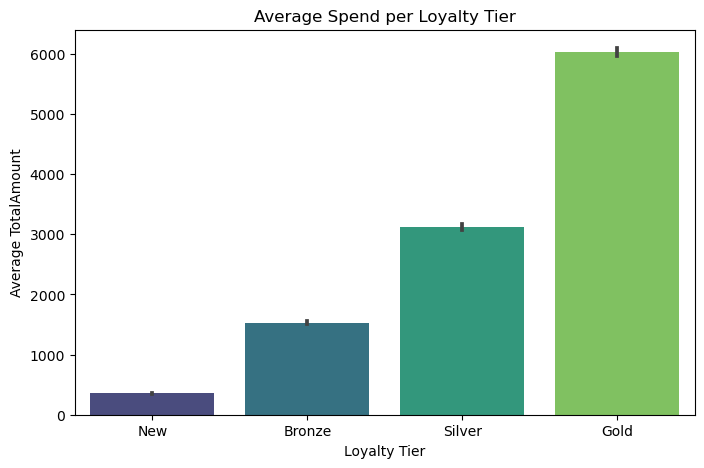

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_viz,
    x="LoyaltyTier",
    y="TotalAmount",
    estimator='mean',
    palette="viridis",
    order=["New", "Bronze", "Silver", "Gold"]
)
plt.title("Average Spend per Loyalty Tier")
plt.ylabel("Average TotalAmount")
plt.xlabel("Loyalty Tier")
plt.show()



#### Loyalty Tier vs Tenure

From the chart, we observe a clear upward trend in tenure as we move from the New tier to Gold. New tier customers typically have a short tenure, mostly clustered around 1–10 months, indicating they are recently acquired. Bronze customers have a broader spread, with tenures ranging from about 10 to 45 months, suggesting moderate engagement. Silver tier members have a tenure distribution concentrated between 30 and 60 months, while Gold customers show consistently long associations, with most tenures above 60 months and tightly grouped around the maximum of 72 months.

This progression confirms the logic of loyalty tier classification — longer-tenured customers are recognized with higher tier status. The narrow interquartile range and fewer outliers in the Gold tier indicate that these customers are not only consistent but also represent a stable and mature user base. Overall, this plot strengthens the case for implementing tier-based strategies for rewards, retention, and personalized engagement.


StatementMeta(, 1ab6d312-46eb-432f-89fb-e23c37c13094, 13, Finished, Available, Finished)

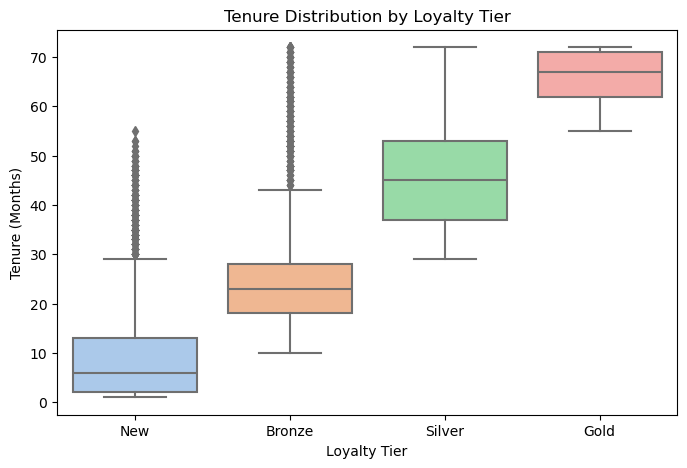

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_viz,
    x="LoyaltyTier",
    y="tenure",
    palette="pastel",
    order=["New", "Bronze", "Silver", "Gold"]
)
plt.title("Tenure Distribution by Loyalty Tier")
plt.ylabel("Tenure (Months)")
plt.xlabel("Loyalty Tier")
plt.show()



#### Churn Rate by Loyalty Tier

The bar chart titled "Churn Distribution Across Loyalty Tiers" provides key insights into customer retention across the different loyalty segments — New, Bronze, Silver, and Gold:

Highest Churn in New Tier:
The New loyalty tier has the highest number of customers who have churned. This suggests that new customers are more likely to leave if not engaged or incentivized properly early in their journey.

Improved Retention with Loyalty Progression:
As we move from New to Gold, the number of churned customers significantly decreases. This indicates a strong positive correlation between loyalty tier and retention — customers in higher tiers are more loyal and less likely to churn.

Gold Tier Shows Strong Loyalty:
The Gold tier has the lowest number of churned customers and a high number of retained customers. This validates that long-tenured and high-spending customers are more engaged and committed to the brand.

Bronze and Silver Tiers Are Transition Points:
While churn still exists in the Bronze and Silver tiers, the drop is substantial compared to the New tier. These tiers may be critical in determining whether a customer can be nurtured toward higher loyalty or risks being lost.

Business Implication:
Retention efforts should focus on New customers with targeted onboarding, welcome offers, and proactive support.

Bronze and Silver customers can be influenced through loyalty rewards and personalized engagement to push them toward the Gold tier.

The Gold tier strategy should focus on appreciation and exclusivity to maintain their loyalty and encourage advocacy.


StatementMeta(, 1ab6d312-46eb-432f-89fb-e23c37c13094, 14, Finished, Available, Finished)

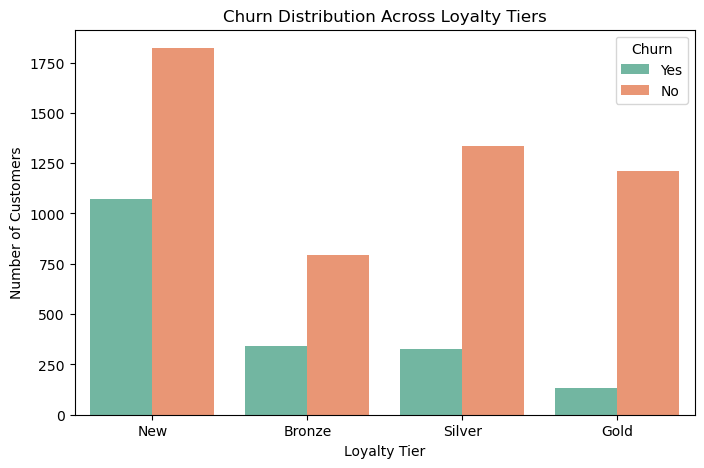

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_viz,
    x="LoyaltyTier",
    hue="Churn",
    palette="Set2",
    order=["New", "Bronze", "Silver", "Gold"]
)
plt.title("Churn Distribution Across Loyalty Tiers")
plt.ylabel("Number of Customers")
plt.xlabel("Loyalty Tier")
plt.show()


#### Discount Percentage by Tier 

The bar chart titled "Assigned Discount Percentage by Tier" provides a clear visualization of how discount percentages are strategically allocated across customer loyalty tiers — New, Bronze, Silver, and Gold:

Key Insights:
Progressive Incentivization:
The discount percentage increases steadily as customers move up the loyalty ladder — starting at 5% for New and Bronze tiers, rising to 10% for Silver, and reaching 15% for Gold.
This reflects a tiered loyalty strategy where greater rewards are given to more loyal, long-standing customers.

Retention & Motivation Tool:
Higher discounts for Silver and Gold customers serve as a retention incentive, encouraging continued engagement and spending. At the same time, it motivates customers in the lower tiers to increase their activity to reach higher levels.

Uniform Entry-Level Benefits:
Both New and Bronze customers receive the same discount (5%), possibly indicating that Bronze is more of a transitional tier, and the major benefit leap begins at the Silver level.

Business Implication:
This discount structure supports a loyalty-driven business model, where customers are rewarded proportionally to their tenure and contribution. It encourages upward mobility through the tiers and helps in retaining high-value customers by offering them stronger incentives, ultimately increasing customer lifetime value.


StatementMeta(, 1ab6d312-46eb-432f-89fb-e23c37c13094, 15, Finished, Available, Finished)

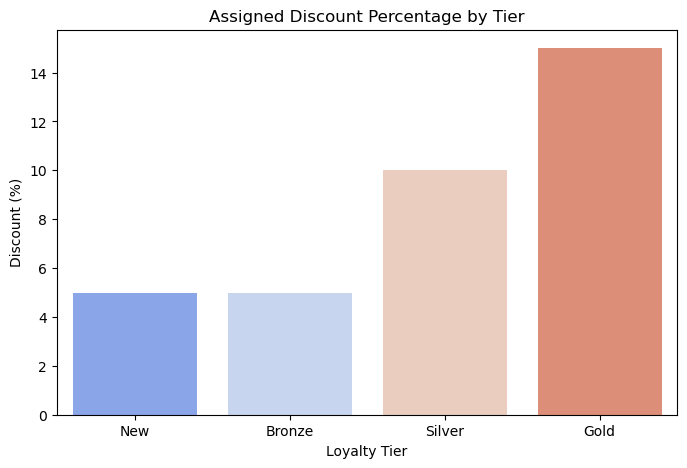

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_viz,
    x="LoyaltyTier",
    y="SuggestedDiscount",
    estimator='mean',
    palette="coolwarm",
    order=["New", "Bronze", "Silver", "Gold"]
)
plt.title("Assigned Discount Percentage by Tier")
plt.ylabel("Discount (%)")
plt.xlabel("Loyalty Tier")
plt.show()



## Summary Table of Tiers

In [14]:
tier_order = ["New", "Bronze", "Silver", "Gold"]

# Create summary
summary = df_viz.groupby("LoyaltyTier").agg({
    "TotalAmount": "mean",
    "tenure": "mean",
    "SuggestedDiscount": "first"
}).round(2).reindex(tier_order).reset_index()

# Display
print(summary)



StatementMeta(, 1ab6d312-46eb-432f-89fb-e23c37c13094, 16, Finished, Available, Finished)

  LoyaltyTier  TotalAmount  tenure  SuggestedDiscount
0         New       358.35   10.15                  5
1      Bronze      1527.52   28.62                  5
2      Silver      3121.50   46.55                 10
3        Gold      6025.36   66.08                 15
